<a href="https://colab.research.google.com/github/aanyagoel14/AanyaWebsite-Onepage/blob/main/StockPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas_datareader
!pip install tensorflow
!pip install yfinance

In [ ]:
import math
import pandas as pd
import numpy as np
import pandas_datareader as web
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import yfinance as yf

In [ ]:
# df = web.DataReader('AAPL', data_source='yahoo', start='2015-01-01', end='2024-12-27')
df = yf.download('AAPL', start='2015-01-01', end='2022-12-27')

[*********************100%%**********************]  1 of 1 completed


In [ ]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,27.847500,27.860001,26.837500,27.332500,24.402164,212818400
2015-01-05,27.072500,27.162500,26.352501,26.562500,23.714724,257142000
2015-01-06,26.635000,26.857500,26.157499,26.565001,23.716953,263188400
2015-01-07,26.799999,27.049999,26.674999,26.937500,24.049520,160423600
2015-01-08,27.307501,28.037500,27.174999,27.972500,24.973558,237458000
...,...,...,...,...,...,...
2022-12-19,135.110001,135.199997,131.320007,132.369995,131.288406,79592600
2022-12-20,131.389999,133.250000,129.889999,132.300003,131.218979,77432800
2022-12-21,132.979996,136.809998,132.750000,135.449997,134.343216,85928000


In [ ]:
df.shape

(2010, 6)

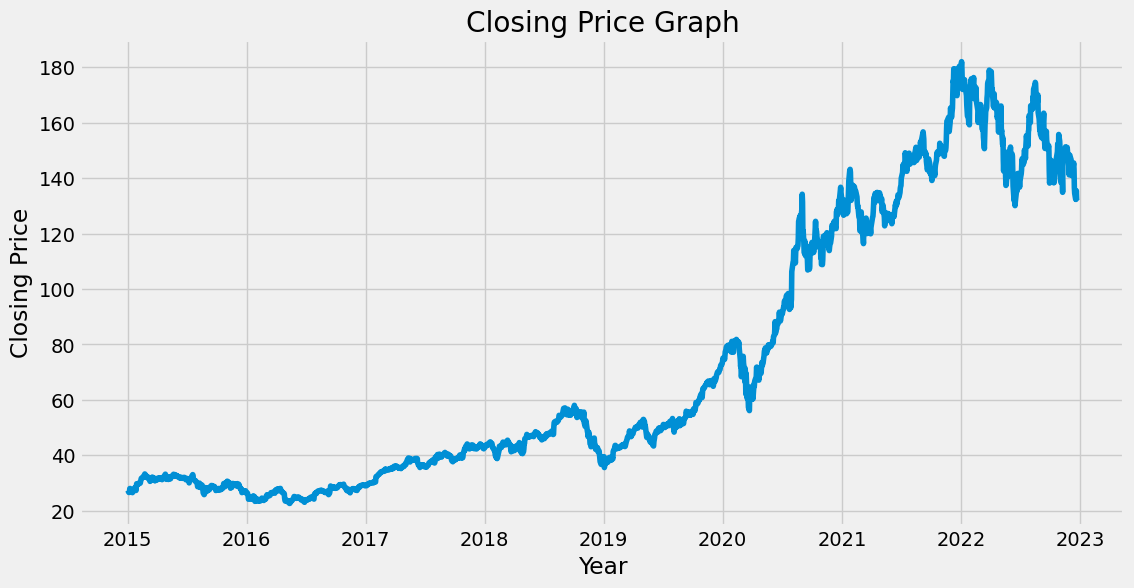

In [ ]:
#plotting closing price history
plt.figure(figsize=(12,6))
plt.title("Closing Price Graph")
plt.plot(df['Close'])
plt.xlabel('Year')
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

In [ ]:
data = df.filter(['Close'])

In [ ]:
data

,Close
Date,
2015-01-02,27.332500
2015-01-05,26.562500
2015-01-06,26.565001
2015-01-07,26.937500
2015-01-08,27.972500
...,...
2022-12-19,132.369995
2022-12-20,132.300003
2022-12-21,135.449997


In [ ]:
#convert dataframe into NumPy array
dataset = data.values
dataset

last_five = dataset[-5:]
print(last_five)


[[132.36999512]
 [132.30000305]
 [135.44999695]
 [132.22999573]
 [131.86000061]]


In [ ]:
#get number of rows on which you want to train model on (80%)
training_data_len = math.ceil(len(dataset) * 0.8)
training_data_len

1608

In [ ]:
print(f"Original min: {dataset.min()}")
print(f"Original max: {dataset.max()}")


Original min: 22.584999084472656
Original max: 182.00999450683594


In [ ]:
#scaling the data- easy to train
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
scaled_data

last_five = scaled_data[-5:]

print(last_five)


[[0.68863101]
 [0.68819198]
 [0.70795045]
 [0.68775286]
 [0.68543205]]


In [ ]:
#create training data
train_data = scaled_data[0:training_data_len, :]

#split data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
  x_train.append(train_data[i-60:i, 0]) #will take from 0 to 59 (first 60)
  y_train.append(train_data[i, 0]) #will take next 60 from 60-
  # if i<=60: #will print x_train and first label of y_train
  if i<=61:   #will print x_train and first two label of y_train
    print(x_train)
    print(y_train)
    print()


[array([0.0297789 , 0.02494904, 0.02496473, 0.02730125, 0.03379333,
       0.03398151, 0.02965345, 0.03117454, 0.03051593, 0.02584288,
       0.02454132, 0.02882234, 0.03012389, 0.03459308, 0.0355026 ,
       0.03569077, 0.02948095, 0.03915635, 0.04478596, 0.04205741,
       0.04436256, 0.04439393, 0.04582092, 0.04641682, 0.044833  ,
       0.04607183, 0.04967853, 0.0541634 , 0.05664106, 0.05761331,
       0.05878941, 0.06018505, 0.05976165, 0.06140819, 0.06689667,
       0.06559511, 0.06029481, 0.06285087, 0.05977734, 0.06076525,
       0.06118866, 0.05990277, 0.05656266, 0.0568606 , 0.05770739,
       0.0535832 , 0.05002353, 0.0534891 , 0.05214051, 0.05427317,
       0.05755058, 0.05979302, 0.05827192, 0.05576291, 0.05781716,
       0.05700174, 0.0518112 , 0.0531598 , 0.05160735, 0.05649993])]
[0.053457746504823156]

[array([0.0297789 , 0.02494904, 0.02496473, 0.02730125, 0.03379333,
       0.03398151, 0.02965345, 0.03117454, 0.03051593, 0.02584288,
       0.02454132, 0.02882234, 0.0

In [ ]:
#converting x_train & y_train to numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
#lstm (expects 3d data) but now we have 2d so need to reshape data
x_train.shape
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1)) #feature= Close price= 1

In [ ]:
#create lstm model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape = (x_train.shape[1], 1))) #adding layer
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

In [ ]:
#compile the model
model.compile(optimizer= 'adam', loss= 'mean_squared_error')

In [ ]:
#train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

1548/1548 ━━━━━━━━━━━━━━━━━━━━ 50s 30ms/step - loss: 0.0026


In [ ]:
#create testing dataset
#create a new array containing scaled values from index 1543 to 2003
test_data = scaled_data[training_data_len - 60: , :]

#create x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range (60, len(test_data)):
  x_test.append(test_data[i-60:i, 0])


In [ ]:
#convert dataset in array
x_test = np.array(x_test)

#reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [ ]:
#get predicted values of the model
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions) #unscaling

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [ ]:
#get the root mean squared error (RMSE)
rmse = np.sqrt( np.mean(predictions - y_test)**2 )
rmse

6.067937575762545

<ipython-input-81-6192469681fd>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


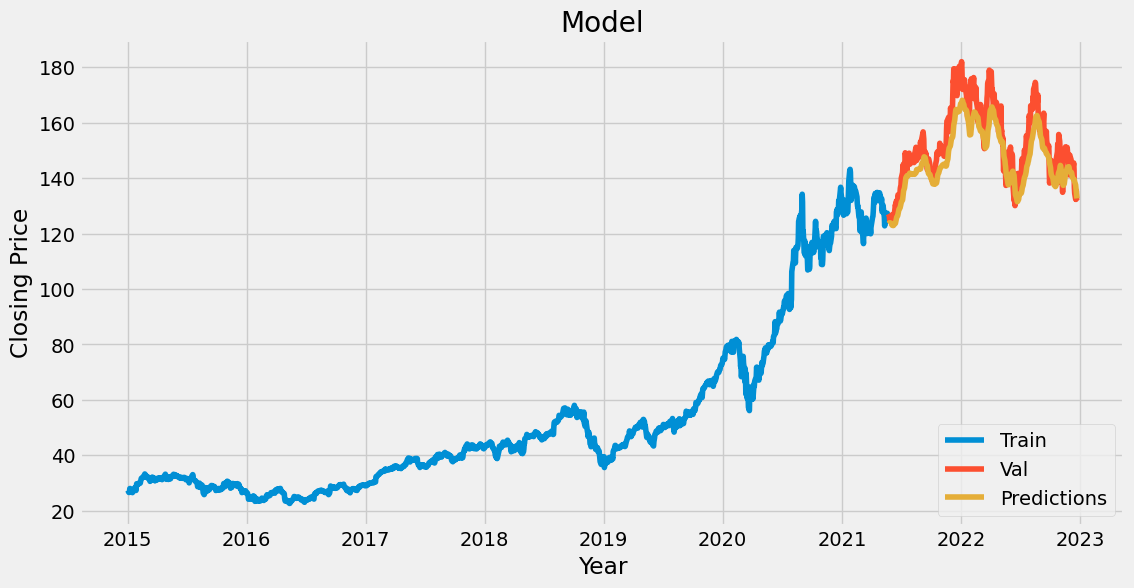

In [ ]:
#plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

#visualizations
plt.figure(figsize=(12,6))
plt.title("Model")
plt.plot(train['Close'])
plt.plot(valid['Close', 'Predictions'])
plt.xlabel('Year')
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

,Close,Predictions
Date,,
2021-05-24,127.099998,123.513794
2021-05-25,126.900002,123.607727
2021-05-26,126.849998,123.745865
2021-05-27,125.279999,123.888855
2021-05-28,124.610001,123.874161
...,...,...
2022-12-19,132.369995,137.523346
2022-12-20,132.300003,136.098007
2022-12-21,135.449997,134.658173
